### STUDY :-1
### Toyota Corolla Price Prediction (Multi-Linear Regression)

###  Objective
- To build a multi-linear regression model to predict the price of Toyota Corolla cars using various features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error

In [2]:
df = pd.read_csv(r"C:\Users\mahesh\Documents\Assignment_2\Toyota_Corolla.csv",encoding = 'latin1')
df.head()

,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Central_Lock,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,...,1,1,1,0,0,0,1,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,...,1,0,1,0,0,0,1,0,0,0
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,...,0,0,1,0,0,0,1,0,0,0
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,...,0,0,1,0,0,0,1,0,0,0
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,...,1,1,1,0,1,0,1,0,0,0


In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 38 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Id                1436 non-null   int64 
 1   Model             1436 non-null   object
 2   Price             1436 non-null   int64 
 3   Age_08_04         1436 non-null   int64 
 4   Mfg_Month         1436 non-null   int64 
 5   Mfg_Year          1436 non-null   int64 
 6   KM                1436 non-null   int64 
 7   Fuel_Type         1436 non-null   object
 8   HP                1436 non-null   int64 
 9   Met_Color         1436 non-null   int64 
 10  Color             1436 non-null   object
 11  Automatic         1436 non-null   int64 
 12  cc                1436 non-null   int64 
 13  Doors             1436 non-null   int64 
 14  Cylinders         1436 non-null   int64 
 15  Gears             1436 non-null   int64 
 16  Quarterly_Tax     1436 non-null   int64 
 17  Weight        

,Id,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,HP,Met_Color,Automatic,cc,...,Central_Lock,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Tow_Bar
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,...,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000
mean,721.555014,10730.824513,55.947075,5.548747,1999.625348,68533.259749,101.502089,0.674791,0.055710,1576.85585,...,0.580084,0.561978,0.977716,0.146240,0.256964,0.300139,0.770195,0.204735,0.145543,0.277855
std,416.476890,3626.964585,18.599988,3.354085,1.540722,37506.448872,14.981080,0.468616,0.229441,424.38677,...,0.493717,0.496317,0.147657,0.353469,0.437111,0.458478,0.420854,0.403649,0.352770,0.448098
min,1.000000,4350.000000,1.000000,1.000000,1998.000000,1.000000,69.000000,0.000000,0.000000,1300.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,361.750000,8450.000000,44.000000,3.000000,1998.000000,43000.000000,90.000000,0.000000,0.000000,1400.00000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
50%,721.500000,9900.000000,61.000000,5.000000,1999.000000,63389.500000,110.000000,1.000000,0.000000,1600.00000,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,1081.250000,11950.000000,70.000000,8.000000,2001.000000,87020.750000,110.000000,1.000000,0.000000,1600.00000,...,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000
max,1442.000000,32500.000000,80.000000,12.000000,2004.000000,243000.000000,192.000000,1.000000,1.000000,16000.00000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Data Cleaning

In [4]:
df.isnull().sum()

Id                  0
Model               0
Price               0
Age_08_04           0
Mfg_Month           0
Mfg_Year            0
KM                  0
Fuel_Type           0
HP                  0
Met_Color           0
Color               0
Automatic           0
cc                  0
Doors               0
Cylinders           0
Gears               0
Quarterly_Tax       0
Weight              0
Mfr_Guarantee       0
BOVAG_Guarantee     0
Guarantee_Period    0
ABS                 0
Airbag_1            0
Airbag_2            0
Airco               0
Automatic_airco     0
Boardcomputer       0
CD_Player           0
Central_Lock        0
Powered_Windows     0
Power_Steering      0
Radio               0
Mistlamps           0
Sport_Model         0
Backseat_Divider    0
Metallic_Rim        0
Radio_cassette      0
Tow_Bar             0
dtype: int64

### No Missing Values Found
- Dataset is clean and ready for analysis

In [5]:
df = df.drop(['Id'],axis=1)
df = df.drop(['Model'],axis=1)
            

In [6]:
df = pd.get_dummies(df,drop_first=True)

### Encoding Done
- Categorical variables converted into numerical using one-hot encoding.

### EDA

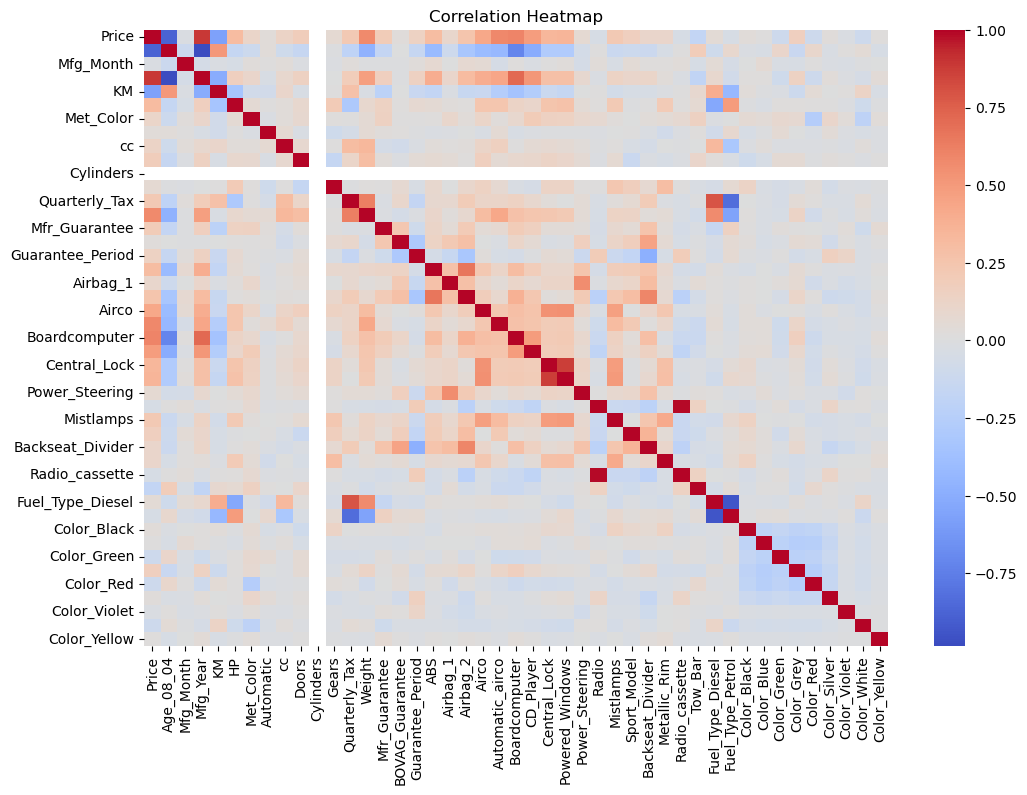

In [7]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [8]:
X1 = df.drop('Price',axis=1)
y = df['Price']

In [9]:
### Train_test_split

X1_train, X1_test, y_train, y_test = train_test_split(X1,y,test_size=0.2,random_state=42)

#### Model Building ( Multi-Linear Regression)

In [10]:
### Model-1 (All Features)

model1= LinearRegression()
model1.fit(X1_train,y_train)

y_pred1 = model1.predict(X1_test)

r2_score1 = r2_score(y_test,y_pred1)
rmse_1 = np.sqrt(mean_squared_error(y_test,y_pred1))

print("r2_score1-",r2_score1)
print("rmse_1-",rmse_1)

r2_score1- 0.8867590446456088
rmse_1- 1229.207124838081


In [11]:
### Model-2 (Important  Features Only)

important_features = ['Age_08_04', 'KM', 'HP', 'Weight', 'Quarterly_Tax']

X2 = df[important_features]

X2_train, X2_test, y_train, y_test = train_test_split(X2, y, test_size=0.2, random_state=42)

model2 = LinearRegression()
model2.fit(X2_train, y_train)

y_pred2 = model2.predict(X2_test)

r2_score2 = r2_score(y_test, y_pred2)
rmse_2 = np.sqrt(mean_squared_error(y_test,y_pred2))

print("r2_score2:", r2_score2)
print("rmse_2:",rmse_2)

r2_score2: 0.8528368926585098
rmse_2: 1401.2730878884822


In [12]:
### Model-3 (Top Correlated Features)

corr = df.corr()['Price'].abs().sort_values(ascending=False)
top_features = corr[1:8].index  # top 7 features

X3 = df[top_features]

X3_train, X3_test, y_train, y_test = train_test_split(X3, y, test_size=0.2, random_state=42)

model3 = LinearRegression()
model3.fit(X3_train, y_train)

y_pred3 = model3.predict(X3_test)

r2_score3 = r2_score(y_test, y_pred3)
rmse_3 = np.sqrt(mean_squared_error(y_test,y_pred3))

print("r2_score3:", r2_score3)
print("rmse_3:",rmse_3)

r2_score3: 0.8728826773740113
rmse_3: 1302.3438847613488


### R^2 Comparison Table

In [13]:
results = pd.DataFrame({'Model':['All Features','Important Features','Top Correlated'],
                        'R2_Score':[r2_score1,r2_score2,r2_score3]
                       }
                      )
results

,Model,R2_Score
0,All Features,0.886759
1,Important Features,0.852837
2,Top Correlated,0.872883


### insight
- Model with highest R^2 is selected as final model.
- Top Correlated features model improved the performance and achieved r2 score nearby to All features model.

In [14]:
final_model =model1

final_predictions = final_model.predict(X1_test)

In [15]:
predictions = pd.DataFrame({
    'Actual':y_test,
    'Predicted':final_predictions
})

predictions.to_csv(r"C:\Users\mahesh\Documents\Assignment_2\Toyota_Corolla_predictions.csv", index=False)
predictions.head()

,Actual,Predicted
594,10800,10288.190481
754,9950,9219.138913
630,7500,9453.691917
1259,9250,8383.239417
903,9750,8748.025171


## Predictions

- Predictions have been generated and saved as a CSV file.
- This file can be used for further analysis or reporting.

## Conclusion

- Successfully built a Multiple Linear Regression model.
- Identified important features affecting car price.
- All features model achieved high accuracy with R² score of 0.89.